In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
sns.set_theme(style="whitegrid")

In [8]:
df = pd.read_csv("Housing.csv")

In [9]:
target_candidates = [col for col in df.columns if col.lower() == 'price']
if target_candidates:
    target_col = target_candidates[0]
else:
    raise KeyError("Target column 'Price' not found in Housing dataset.")

In [10]:
if not np.issubdtype(df[target_col].dtype, np.number):
    df[target_col] = pd.to_numeric(
        df[target_col].astype(str).str.replace(r'[\$,]', '', regex=True),
        errors='coerce'
    )

In [19]:
numeric_df = df.select_dtypes(include=[np.number]).dropna()

# Separate features (X) and target variable (y)
X = numeric_df.drop(columns=[target_col])
y = numeric_df[target_col]

print(f"\nTarget Column: '{target_col}'")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Features list: {list(X.columns)}")



Target Column: 'price'
Features (X) shape: (545, 5)
Target (y) shape: (545,)
Features list: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining Set Size: {X_train.shape[0]} samples")
print(f"Testing Set Size: {X_test.shape[0]} samples")


Training Set Size: 436 samples
Testing Set Size: 109 samples


In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Model Coefficients ---")
print(coefficients_df.to_string(index=False))
print(f"Intercept: {model.intercept_:.4f}")

# Cell 6: Make Predictions & Calculate Metrics
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE)     : ${mae:,.2f}")
print(f"Mean Squared Error (MSE)      : {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score                      : {r2:.4f}")


--- Model Coefficients ---
  Feature  Coefficient
bathrooms 1.185732e+06
  stories 4.951008e+05
  parking 3.376608e+05
 bedrooms 1.512468e+05
     area 3.088670e+02
Intercept: 51999.6768
Mean Absolute Error (MAE)     : $1,127,483.35
Mean Squared Error (MSE)      : 2,292,721,545,725.36
Root Mean Squared Error (RMSE): $1,514,173.55
R² Score                      : 0.5464


In [45]:
results_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': np.round(y_pred, 2),
    'Residual': np.round(y_test.values - y_pred, 2)
})

print("\n--- Sample Prediction Results (First 10 Rows) ---")
print(results_df.head(10))


--- Sample Prediction Results (First 10 Rows) ---
   Actual Price  Predicted Price    Residual
0       4060000       6178627.50 -2118627.50
1       6650000       6370140.86   279859.14
2       3710000       3283148.16   426851.84
3       6440000       4226007.95  2213992.05
4       2800000       3409685.55  -609685.55
5       4900000       4262158.35   637841.65
6       5250000       5493440.53  -243440.53
7       4543000       5559897.74 -1016897.74
8       2450000       3373715.42  -923715.42
9       3353000       3020513.19   332486.81


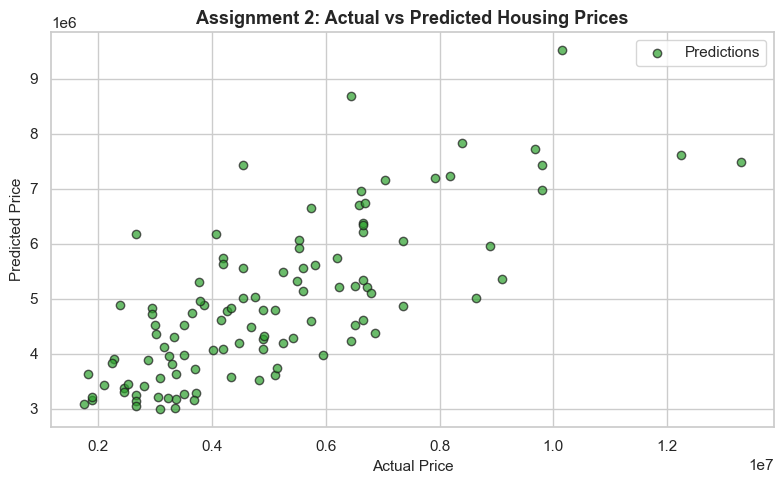

In [66]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='#2ca02c', alpha=0.7, edgecolors='k', label='Predictions')

plt.title('Assignment 2: Actual vs Predicted Housing Prices', fontsize=13, fontweight='bold')
plt.xlabel('Actual Price', fontsize=11)
plt.ylabel('Predicted Price', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

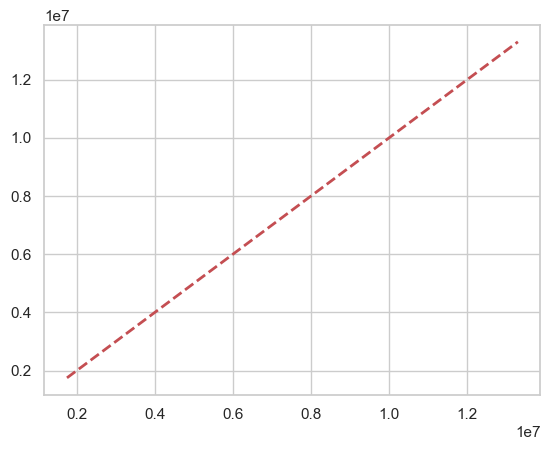

In [57]:
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit (Actual = Predicted)')
